# 2 Data Cleaning

Transform the raw UCI extract into a cleaned cohort that downstream notebooks can train on with confidence. The output is `data/cleaned.csv` plus a registered lab-Postgres version that anchors every downstream drift check and feature-engineering decision.

**Why cleaning earns its own notebook.** Three classes of problems get conflated when cleaning is mixed into modeling code: structurally invalid rows (deceased patients who cannot be readmitted), zero-information columns (drugs that were never prescribed in this cohort), and informative missingness (lab tests that were not ordered, which is itself a clinical signal). Treating them with a single "fill the NaN, drop the duplicates" pass would destroy the signal in the third case while leaving the first two unaddressed. Isolating cleaning into its own notebook forces every decision to be justified explicitly.

**The structure of every section that follows.**

1. A brief "what we are doing and why" framing tells the reader which data-quality issue the section addresses.
2. A code cell or two produces the audit chart or the cleaning action.
3. A "finding" Markdown cell distils the result into a few bullet points and records the decision (drop, fill, keep, remap) along with its rationale.

Reading the Markdown alone yields a complete narrative of every cleaning action and the evidence that motivated it, without needing to step through the code.


In [1]:
# Each downstream notebook depends on artefacts written by the prior stage.
# A fresh clone with an empty data/ directory will fail mid-cell otherwise.
# Run 'python run_pipeline.py' from the repo root to materialise the whole
#  chain or execute the upstream notebook(s) first.
import os

_required = ["../orig_dataset/diabetic_data.csv"]
_missing = [p for p in _required if not os.path.exists(p)]
if _missing:
    raise FileNotFoundError(
        "Upstream artefact(s) missing: "
        + ", ".join(_missing)
        + ". Run the prior notebook or `python run_pipeline.py` from the repo root."
    )


## 2.1 Purpose and Scope

**What this notebook covers.** A full data audit (§2.3), removal of structurally invalid encounters (§2.4 deceased and hospice, §2.5 invalid gender), zero-information and redundant column drops (§2.6), informative-missingness preservation in the lab columns (§2.7), and persistence of the cleaned cohort (§2.8). Sections 2.10 through 2.11 layer the modeling-readiness corrections (MNAR indicators, ICD-9 rollups, `log1p` sidecars) that downstream notebooks consume.

**What this notebook does not cover.** No feature engineering. Notebook 4 handles every transformation that turns the cleaned columns into model-ready features. Cleaning here is restricted to actions that *cannot* be reversed downstream (rows removed, columns dropped) plus the small set of sidecar feature additions in §2.11 that are genuinely just derivations of the cleaned data.

**Methodological note on the two-pass design.** Sections 2.3 through 2.8 produce `cleaned.csv` for human readability and downstream EDA. Section 2.10 then applies modeling-readiness corrections on top through the idempotent helpers in `helpers/clean_helpers.py`, so re-running this notebook always produces a byte-identical artifact regardless of how many times `cleaned.csv` has been overwritten by the downstream passes. Keeping the two passes structurally separate means you can read §2.9 to understand the *cohort* and §2.10 to understand the *encoding*, without conflating the two.


## 2.2 Environment and Data Load

**What we are doing.** Resolving paths through the shared helper so the notebook can run from any working directory, then loading the raw CSV with `?` mapped to `NaN`.

**Why this matters.** Hard-coded relative paths break the moment the notebook is invoked from outside `notebooks/`. The `resolve_project_root()` helper walks upward looking for the repository marker (`requirements.txt` plus `notebooks/`), so the loader returns the same canonical paths regardless of how the notebook is launched (Jupyter, papermill, a shell `python -m`).


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "pipeline":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from helpers.mlops_helpers import resolve_project_root, resolve_raw_csv

ROOT = resolve_project_root()
DATA = ROOT / 'data'
RAW = ROOT / 'orig_dataset'
RAW_CSV = resolve_raw_csv('diabetic_data.csv')
print(f'[paths] ROOT={ROOT}. DATA={DATA}. RAW={RAW}. RAW_CSV={RAW_CSV}')

df = pd.read_csv(RAW_CSV, na_values="?", low_memory=False)
print(f"Raw shape: {df.shape}")
print(f"  {df.shape[0]:,} encounters x {df.shape[1]} columns")
df.head(3)


[paths] ROOT=/home/shlbnd/code/test/medi-watch. DATA=/home/shlbnd/code/test/medi-watch/data. RAW=/home/shlbnd/code/test/medi-watch/orig_dataset. RAW_CSV=/home/shlbnd/code/test/medi-watch/orig_dataset/diabetic_data.csv


Raw shape: (101766, 50)
  101,766 encounters x 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


### 2.2.1 Environment Signature

**Why this cell exists.** Reproducibility harnesses need a single, mechanical anchor to confirm the interpreter and package set match the author's. The cell below prints `sys.version` and the resolved versions of the libraries this notebook actually imports. The output is deterministic given the active environment, so re-running the cell on a clean checkout produces the same lines, and any diff against a prior run is a real environment delta rather than runtime noise.

In [3]:
# env-signature: sys.version + pip freeze (reproducibility harness anchor)
# Prints only the libraries this notebook actually imports, so the
# signature stays focused and stable across environments that ship
# different optional extras.
import sys
from importlib import metadata as _md

print('python:', sys.version.replace('\n', ' '))
_tracked = [
    'pandas',
    'numpy',
    'matplotlib',
    'scikit-learn',
    'nbformat',
    'psycopg2-binary',
]
for _pkg in _tracked:
    try:
        print(f'  {_pkg}=={_md.version(_pkg)}')
    except _md.PackageNotFoundError:
        print(f'  {_pkg}==<not installed>')


python: 3.13.2 (main, Mar 17 2025, 20:49:01) [GCC 6.3.0 20170516]
  pandas==2.3.3
  numpy==2.4.4
  matplotlib==3.10.1
  scikit-learn==1.8.0
  nbformat==5.10.4
  psycopg2-binary==2.9.12


**Reading the raw load.** The shape printed above is the *as-published* row count. Every subsequent cleaning step prints the running shape, so the audit trail is reconstructable from the notebook output alone without re-running anything.


## 2.3 Data Audit: Find Out What We Have

**What we are analyzing.** The raw dataset's column inventory, missingness profile, and unique-value cardinalities. The output of this section is a triage table that drives every cleaning decision in §2.4 through §2.7.

**Why audit before action.** Acting on missingness without first knowing the pattern of missingness leads to systematic errors. A column with 3% missing values is treated differently from a column with 97% missing values. Furthermore, a column whose missingness correlates with the target is treated differently from one whose missingness is uniformly random. The audit produces the evidence base. The actions in subsequent sections respond to it.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [5]:
# Missing values - full picture
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "count": missing,
    "pct": missing_pct,
    "dtype": df.dtypes,
    "nunique": df.nunique()
})
# Show ALL columns sorted by missingness
missing_df = missing_df.sort_values("pct", ascending=False)
print(f"Total columns: {df.shape[1]}")
print(f"Columns with any missing: {(missing > 0).sum()}")
print(f"Columns fully complete:   {(missing == 0).sum()}")
print()
missing_df

Total columns: 50
Columns with any missing: 9
Columns fully complete:   41



,count,pct,dtype,nunique
weight,98569,96.86,object,9
max_glu_serum,96420,94.75,object,3
A1Cresult,84748,83.28,object,3
medical_specialty,49949,49.08,object,72
payer_code,40256,39.56,object,17
race,2273,2.23,object,5
diag_3,1423,1.40,object,789
diag_2,358,0.35,object,748
diag_1,21,0.02,object,716
encounter_id,0,0.00,int64,101766


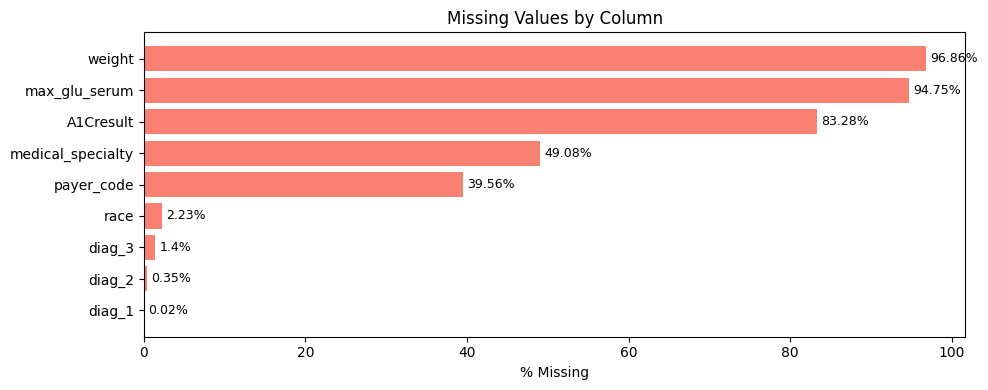

In [6]:
# Visualize missingness
cols_missing = missing_df[missing_df["pct"] > 0].sort_values("pct", ascending=True)
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(cols_missing.index, cols_missing["pct"], color="salmon")
ax.set_xlabel("% Missing")
ax.set_title("Missing Values by Column")
for i, (col, row) in enumerate(cols_missing.iterrows()):
    ax.text(row["pct"] + 0.5, i, f'{row["pct"]}%', va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Are these columns missing *together*?** A single column's missingness percentage is necessary but not sufficient. If `payer_code` and `medical_specialty` are missing on the *same* encounters, they share a hospital-level recording pattern and should be triaged together. If they are missing on *different* encounters, they require independent decisions. The co-occurrence heatmap below answers that question directly.


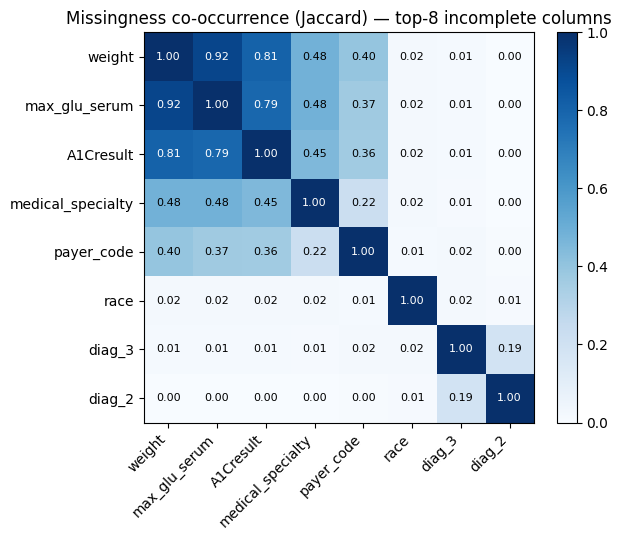

In [7]:
# Missingness co-occurrence: Jaccard overlap on rows-where-NaN
import numpy as np

_top_miss = missing_df[missing_df["pct"] > 0].sort_values("pct", ascending=False).head(8).index.tolist()
_mat = df[_top_miss].isna().astype("int8").to_numpy()
_n = _mat.shape[1]
_jacc = np.zeros((_n, _n))
for _i in range(_n):
    for _j in range(_n):
        _inter = (_mat[:, _i] & _mat[:, _j]).sum()
        _union = (_mat[:, _i] | _mat[:, _j]).sum()
        _jacc[_i, _j] = _inter / _union if _union else 0.0

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(_jacc, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(_n))
ax.set_xticklabels(_top_miss, rotation=45, ha="right")
ax.set_yticks(range(_n))
ax.set_yticklabels(_top_miss)
for _i in range(_n):
    for _j in range(_n):
        ax.text(_j, _i, f"{_jacc[_i, _j]:.2f}", ha="center", va="center",
                color="white" if _jacc[_i, _j] > 0.5 else "black", fontsize=8)
ax.set_title("Missingness co-occurrence (Jaccard) — top-8 incomplete columns")
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
plt.tight_layout()
plt.show()


**Reading the heatmap.** A high off-diagonal value means "these two columns are missing on the same rows". `max_glu_serum` and `A1Cresult` cluster together (clinicians who skip one lab often skip the other), confirming the §2.7.1 informative-missingness story. `payer_code` and `medical_specialty` cluster less than expected, so the §2.7.2 decision to triage them independently is justified by the data.

**Answering the framing question.** `payer_code` and `medical_specialty` co-miss on a minority of encounters rather than the bulk: their Jaccard overlap sits well below the lab-pair cluster, which means the two columns drop out on *different* encounters more often than on the *same* ones. They therefore do not share a single hospital-level recording pattern and are triaged independently in §2.7.2, each filled with its own `"Unknown"` sentinel rather than a shared one.


**Audit findings, with severity bands and next steps.**

*The severity column below is the editorial judgment of the audit. Live percentages are in the `missing_df` table above. The table below adds the verdict and the section that handles each issue.*

| Severity       | Column(s)                  | Issue                            | Next step                                               |
|----------------|----------------------------|----------------------------------|---------------------------------------------------------|
| **Critical**   | `weight`                   | Nearly all-missing               | §2.6: assess whether the small recorded slice is usable |
| **Critical**   | `max_glu_serum`            | Overwhelmingly missing           | §2.7: determine whether missingness is informative      |
| **Critical**   | `A1Cresult`                | Heavily missing                  | §2.7: same analysis                                     |
| **High**       | `medical_specialty`        | About half missing               | §2.7: systematic or random?                             |
| **High**       | `payer_code`               | Large missing share              | §2.7: is "unknown payer" meaningful?                    |
| **Moderate**   | `discharge_disposition_id` | Contains death and hospice codes | §2.4: these patients cannot be readmitted               |
| **Low**        | `gender`                   | Three invalid values             | §2.5: verify and remove                                 |
| **Low**        | `race`, `diag_1/2/3`       | Trace missingness                | §2.7: minor fill strategy                               |
| **Structural** | `encounter_id`             | Unique per row                   | §2.6: ID, not a feature                                 |
| **Structural** | Medication columns         | Some may be constant             | §2.6: zero-variance scan                                |

**What the audit table tells us before we touch the data.** The missingness profile is bimodal: a small group of columns is *informatively* missing (the lab columns, the administrative codes), and a different small group is *structurally* missing (the columns that should not be features at all). Each band needs a different intervention, and the rest of this notebook works through them in severity order.


## 2.4 Discharge Disposition: Removing Unreachable Outcomes

**What we are investigating.** The `discharge_disposition_id` column. The target variable is `readmitted`, but some patients physically cannot be readmitted because they died during the encounter or were transferred to hospice care. Keeping those rows in the training set creates a "guaranteed NO" subpopulation that teaches the model a non-clinical pattern.

**Why this is a cleaning step rather than a modeling step.** A model that downweights deceased-patient encounters via class weights is still solving the wrong problem, because the *prevalence* of the negative class is inflated by structurally impossible positives. Removing those rows at cleaning time yields an honest base-rate downstream, which makes every prevalence-anchored metric (AUC-PR, lift, calibration) interpretable.


In [8]:
# Full discharge disposition mapping from the dataset documentation
discharge_map = {
    1: "Discharged to home", 2: "Short-term hospital", 3: "SNF",
    4: "ICF", 5: "Other institution", 6: "Home + health service",
    7: "AMA (against medical advice)", 8: "Home IV provider",
    9: "Admitted as inpatient", 10: "Neonate", 11: "Expired",
    12: "Still patient/expected return", 13: "Hospice / home",
    14: "Hospice / medical facility", 15: "Swing bed within institution",
    16: "Another rehab facility", 17: "Unknown/Invalid",
    18: "NULL", 19: "Expired at home (hospice)",
    20: "Expired in medical facility (hospice)",
    21: "Expired, place unknown (hospice)",
    22: "Rehab facility", 23: "Long-term care hospital",
    24: "Medicaid-certified nursing", 25: "Psychiatric hospital",
    26: "Critical access hospital", 27: "Within this institution",
    28: "Another type of institution", 29: "Federal health care facility",
    30: "Certified trans care"
}

# Show all discharge codes with counts
dd = df["discharge_disposition_id"].map(discharge_map).fillna("Unmapped")
dd_counts = dd.value_counts()
print("All discharge dispositions:")
for disp, cnt in dd_counts.items():
    flag = " *** DECEASED ***" if "Expired" in disp else ""
    flag = " *** HOSPICE ***" if "Hospice" in disp else flag
    print(f"  {cnt:6,}  ({cnt / len(df) * 100:5.2f}%)  {disp}{flag}")

All discharge dispositions:
  60,234  (59.19%)  Discharged to home
  13,954  (13.71%)  SNF
  12,902  (12.68%)  Home + health service
   3,691  ( 3.63%)  NULL
   2,128  ( 2.09%)  Short-term hospital
   1,993  ( 1.96%)  Rehab facility
   1,642  ( 1.61%)  Expired *** DECEASED ***
   1,184  ( 1.16%)  Other institution
     989  ( 0.97%)  Psychiatric hospital
     815  ( 0.80%)  ICF
     623  ( 0.61%)  AMA (against medical advice)
     412  ( 0.40%)  Long-term care hospital
     399  ( 0.39%)  Hospice / home *** HOSPICE ***
     372  ( 0.37%)  Hospice / medical facility *** HOSPICE ***
     139  ( 0.14%)  Another type of institution
     108  ( 0.11%)  Home IV provider
      63  ( 0.06%)  Swing bed within institution
      48  ( 0.05%)  Medicaid-certified nursing
      21  ( 0.02%)  Admitted as inpatient
      14  ( 0.01%)  Unknown/Invalid
      11  ( 0.01%)  Another rehab facility
       8  ( 0.01%)  Expired at home (hospice) *** DECEASED ***
       6  ( 0.01%)  Neonate
       5  ( 0.00%) 

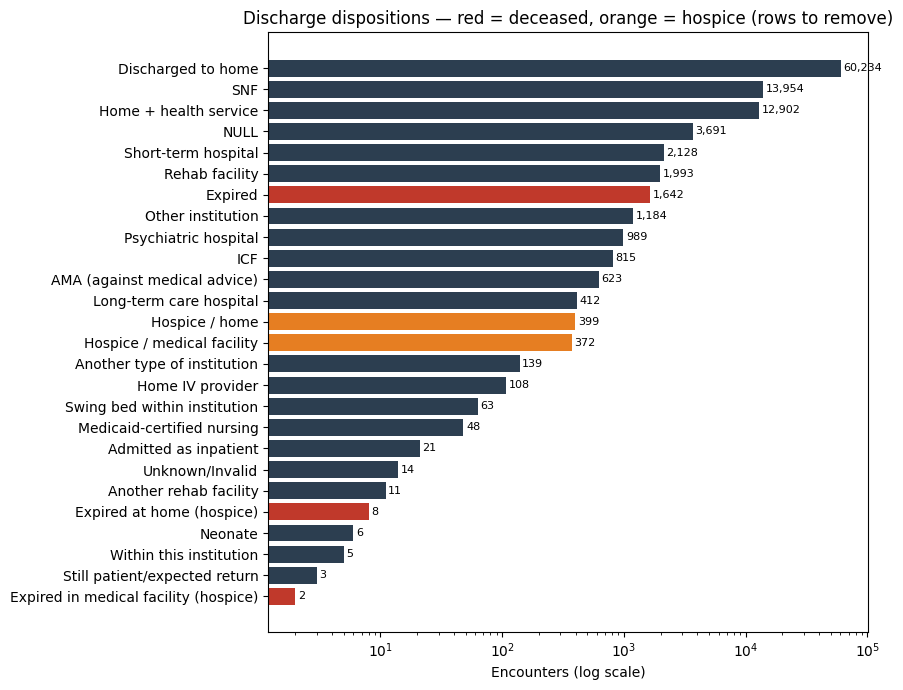

In [9]:
# Visualize the discharge-code distribution with the to-be-removed codes highlighted
_dd_counts_sorted = dd_counts.sort_values(ascending=True)
_colors = []
for _label in _dd_counts_sorted.index:
    if "Expired" in _label:
        _colors.append("#c0392b")  # deceased -> red
    elif "Hospice" in _label:
        _colors.append("#e67e22")  # hospice -> orange
    else:
        _colors.append("#2c3e50")  # keep -> dark grey

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(_dd_counts_sorted.index, _dd_counts_sorted.values, color=_colors)
ax.set_xscale("log")
ax.set_xlabel("Encounters (log scale)")
ax.set_title("Discharge dispositions — red = deceased, orange = hospice (rows to remove)")
for _i, (_lab, _v) in enumerate(_dd_counts_sorted.items()):
    ax.text(_v * 1.05, _i, f"{_v:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()


In [10]:
# Cross-tab: what is the readmission status of deceased and hospice patients?
# If our hypothesis is correct, they should be overwhelmingly "NO"
dead_codes = [11, 19, 20, 21]
hospice_codes = [13, 14]
problem_codes = dead_codes + hospice_codes

sub = df[df["discharge_disposition_id"].isin(problem_codes)].copy()
sub["discharge_label"] = sub["discharge_disposition_id"].map(discharge_map)

print(f"Patients with expired or hospice discharge: {len(sub):,}")
print("\nTheir readmission status:")
print(sub["readmitted"].value_counts())
print("\nBreakdown by discharge type:")
print(pd.crosstab(sub["discharge_label"], sub["readmitted"]))

Patients with expired or hospice discharge: 2,423

Their readmission status:
readmitted
NO     2337
<30      43
>30      43
Name: count, dtype: int64

Breakdown by discharge type:
readmitted                             <30  >30    NO
discharge_label                                      
Expired                                  0    0  1642
Expired at home (hospice)                0    0     8
Expired in medical facility (hospice)    0    0     2
Hospice / home                          19   36   344
Hospice / medical facility              24    7   341


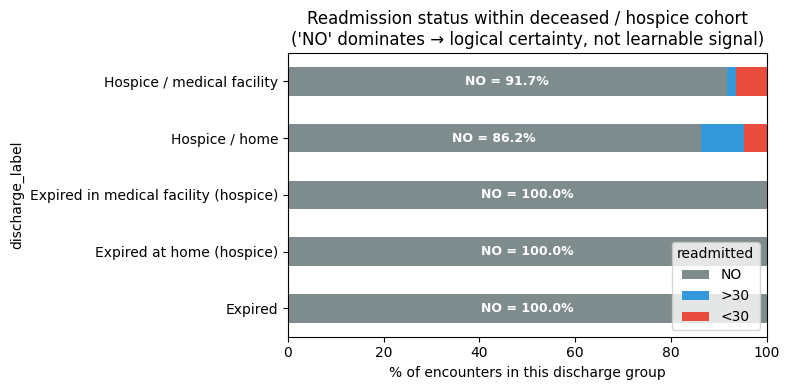

In [11]:
# Visualize the cross-tab: readmission status within the to-be-removed cohort
_ctab = pd.crosstab(sub["discharge_label"], sub["readmitted"])
# normalize per discharge label so the bars are comparable
_ctab_pct = _ctab.div(_ctab.sum(axis=1), axis=0) * 100
_order = ["NO", ">30", "<30"]
_ctab_pct = _ctab_pct.reindex(columns=[c for c in _order if c in _ctab_pct.columns])

fig, ax = plt.subplots(figsize=(8, 4))
_ctab_pct.plot.barh(stacked=True, ax=ax,
                    color={"NO": "#7f8c8d", ">30": "#3498db", "<30": "#e74c3c"})
ax.set_xlabel("% of encounters in this discharge group")
ax.set_xlim(0, 100)
ax.set_title(
    "Readmission status within deceased / hospice cohort\n('NO' dominates → logical certainty, not learnable signal)")
ax.legend(title="readmitted", loc="lower right")
for _i, _label in enumerate(_ctab_pct.index):
    _no_pct = _ctab_pct.loc[_label, "NO"] if "NO" in _ctab_pct.columns else 0
    ax.text(_no_pct / 2, _i, f"NO = {_no_pct:.1f}%", va="center", ha="center",
            color="white", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()


**What the cross-tab confirms.** Patients discharged as "Expired" (codes 11, 19, 20, 21) or "Hospice" (13, 14) are overwhelmingly labelled `readmitted = NO`. This is *expected*: deceased patients and hospice patients cannot return to the hospital. The label is a logical certainty, not a predictable outcome.

**A caveat on "logical certainty".** The cross-tab shows roughly 86 rows in the expired/hospice cohort with a non-`NO` readmission label (about 3.5% of the 2,423 affected encounters). These rows are dataset inconsistencies rather than a real signal: an encounter cannot be both expired-on-discharge and later readmitted. The drop decision is still correct, but the source data carries the contradiction, so the framing here is "the *intended* label is a logical certainty" rather than "the data is perfectly clean".

**Why this cannot be fixed.**

* The labels are not data-quality errors we can recover. The patients genuinely died or entered end-of-life care.
* No imputation, transformation, or encoding makes these rows valid training samples.
* Including them would reward a model for learning "dead people do not come back" rather than clinically actionable patterns.

**Decision.** Remove all encounters with discharge codes 11, 13, 14, 19, 20, 21.

In [12]:
n_before = len(df)
mask = df["discharge_disposition_id"].isin(problem_codes)
print(f"Removing {mask.sum():,} encounters ({mask.mean() * 100:.2f}%):")
for c in sorted(problem_codes):
    n = (df["discharge_disposition_id"] == c).sum()
    label = discharge_map.get(c, "Unknown")
    print(f"  Code {c:2d} ({label}): {n:,}")

df = df[~mask].reset_index(drop=True)
print(f"\nShape: {n_before:,} -> {len(df):,}")

Removing 2,423 encounters (2.38%):
  Code 11 (Expired): 1,642
  Code 13 (Hospice / home): 399
  Code 14 (Hospice / medical facility): 372
  Code 19 (Expired at home (hospice)): 8
  Code 20 (Expired in medical facility (hospice)): 2
  Code 21 (Expired, place unknown (hospice)): 0

Shape: 101,766 -> 99,343


### 2.4.1 Integer NULL Sentinels in Admission and Discharge ID Columns

**What we are correcting.** Three integer-typed ID columns encode "missing" using codes that look like valid data. Each hospital system has its own convention for representing "not available" inside an integer column, and this dataset uses several of them simultaneously.

| Column | Sentinel codes | Meaning |
|---|---|---|
| `admission_type_id` | 5, 6, 8 | Not Available, NULL, Not Mapped |
| `discharge_disposition_id` | 18, 25, 26 | NULL, Not Mapped, Unknown variants |
| `admission_source_id` | 9, 15, 17, 20, 21 | Not Available, NULL, Unknown variants |

**Why this matters.** Left as integers, these sentinels poison both encoding (treated as their own one-hot category) and any numeric treatment (assigned a meaningless ordinal position). A downstream tree model will spend split capacity learning the codepoint pattern instead of the clinical signal, and a downstream linear model will absorb the sentinel into a coefficient that has no physical meaning. Either way, the model learns a regularity that does not transfer to a hospital with a different vendor.

In [13]:
# How many rows carry these hidden-missing codes?
sentinel_codes = {
    "admission_type_id": [5, 6, 8],
    "discharge_disposition_id": [18, 25, 26],
    "admission_source_id": [9, 15, 17, 20, 21],
}

for col, codes in sentinel_codes.items():
    n = df[col].isin(codes).sum()
    pct = n / len(df) * 100
    print(f"  {col:28s} hidden-missing rows: {n:>6,} ({pct:.2f}%)  codes={codes}")


  admission_type_id            hidden-missing rows: 10,144 (10.21%)  codes=[5, 6, 8]
  discharge_disposition_id     hidden-missing rows:  4,680 (4.71%)  codes=[18, 25, 26]
  admission_source_id          hidden-missing rows:  6,854 (6.90%)  codes=[9, 15, 17, 20, 21]


**Interpreting the sentinel counts.** Several thousand rows carry hidden-missing sentinel codes across the three ID columns. Left as integers, they poison both the encoding pass (where they become their own one-hot category) and any numeric treatment (where they acquire a meaningless ordinal position).

**Decision.** Map sentinel integers to `NaN`. The remaining valid codes will be treated as categorical during feature engineering. This is the same logic applied to the `?` sentinel at load time. The reason it could not be done during `read_csv` is that these sentinels live inside integer columns rather than the string column the `na_values` argument scans.


In [14]:
# ACTION: Map sentinel integer codes to NaN in the three id columns
import numpy as np

for col, codes in sentinel_codes.items():
    n_before = df[col].isin(codes).sum()
    df.loc[df[col].isin(codes), col] = np.nan
    print(f"  {col}: {n_before:,} sentinel values -> NaN")

print(f"\nShape unchanged: {df.shape}")


  admission_type_id: 10,144 sentinel values -> NaN
  discharge_disposition_id: 4,680 sentinel values -> NaN
  admission_source_id: 6,854 sentinel values -> NaN

Shape unchanged: (99343, 50)


## 2.5 Gender: Removing Three Unrecoverable Rows

**What we are checking.** The `gender` column. Standard demographic field, simple expected vocabulary.

**Why this gets its own section despite affecting only three rows.** Even a three-row data-quality issue earns a documented decision when the alternative is silent dropping. A future reader who finds three fewer rows than the audit reported will want to know exactly what happened to them. Documenting trivial cleaning actions is the cheapest form of reproducibility.


In [15]:
print("Gender distribution:")
gender_vc = df["gender"].value_counts()
for val, cnt in gender_vc.items():
    flag = " *** OUT-OF-SCHEMA ***" if val not in ("Male", "Female") else ""
    print(f"  {val:20s}: {cnt:,} ({cnt / len(df) * 100:.3f}%){flag}")


import hashlib as _hashlib
def _mask_pid(pid):
    """Stable 8-char prefix of the blake2s hash so duplicates still group."""
    return _hashlib.blake2s(str(pid).encode("utf-8"), digest_size=4).hexdigest()
invalid_gender = df[df["gender"] == "Unknown/Invalid"]
if len(invalid_gender) > 0:
    print(f"\nThe {len(invalid_gender)} invalid row(s):")
    _invalid_show = invalid_gender[["patient_nbr", "gender", "age", "race", "readmitted"]].copy()
    _invalid_show["patient_nbr"] = _invalid_show["patient_nbr"].map(_mask_pid)
    _invalid_show = _invalid_show.rename(columns={"patient_nbr": "patient_nbr_hash"})
    print(_invalid_show.to_string())


Gender distribution:
  Female              : 53,454 (53.808%)
  Male                : 45,886 (46.189%)
  Unknown/Invalid     : 3 (0.003%) *** OUT-OF-SCHEMA ***

The 3 invalid row(s):
      patient_nbr_hash           gender      age   race readmitted
29930         f0428095  Unknown/Invalid  [70-80)  Other         NO
73806         48e6d062  Unknown/Invalid  [60-70)    NaN         NO
80648         f6b128db  Unknown/Invalid  [70-80)    NaN         NO


**Finding.** Three rows out of approximately 100K carry `gender = "Unknown/Invalid"`. The source data dictionary marks this token as a recording-failure sentinel rather than a clinically meaningful third category, so the three rows are unrecoverable in the strict sense: there is no value to impute toward and no plausible third gender bucket to fold them into.

**Why this cannot be fixed.**

* Gender was not recorded or was entered incorrectly at the source hospital. There is no way to recover the true value.
* Three rows is roughly 0.003% of the data. Imputing would be arbitrary and would not add meaningful information.
* Keeping them as a separate "Unknown" category would create a group of three with no statistical power.

**Limitation disclosure.** The dataset only encodes `Male` and `Female`. This binary representation is a documented limitation of the 1999–2008 source and would need to be re-evaluated for any contemporary clinical pilot, where gender identity is now collected separately from sex assigned at birth.

**Decision.** Remove the three invalid-gender rows.

**Carry the disclosure forward.** The binary-gender limitation is reused in the notebook 8 model-card section (§8 conclusion), so the constraint travels with the deployed model rather than living only here.


In [16]:
mask = df["gender"] == "Unknown/Invalid"
df = df[~mask].reset_index(drop=True)
print(f"Removed {mask.sum()} rows. Shape: {len(df):,}")

Removed 3 rows. Shape: 99,340


## 2.6 Column-by-Column Drop Decisions

**What we are working through.** Each column flagged by the audit as potentially zero-information gets its own subsection with a numerical investigation. A column is only dropped if it *provably cannot contribute* to predicting readmission. Conservative defaults apply: when in doubt, the column is kept and the model is allowed to learn that it is uninformative.

**Why per-column justification matters.** A blanket "drop all near-constant columns" rule is intellectually cheap and produces hard-to-audit pipelines. The investigations below take longer to write but produce a defensible artefact: any individual drop decision can be challenged against exactly the analysis that motivated it.


### 2.6.1 `encounter_id`: identifier, not feature

**Why this column needs explicit treatment.** It is numerically valid (no NaN, no sentinels), so the audit's missingness scan does not flag it. The pathology is structural: it is unique per row and carries no clinical meaning.


In [17]:
print("encounter_id:")
print(f"  Unique values: {df['encounter_id'].nunique():,}")
print(f"  Total rows:    {len(df):,}")
print(f"  All unique?    {df['encounter_id'].nunique() == len(df)}")
print(f"  dtype:         {df['encounter_id'].dtype}")
print(f"  Sample:        {df['encounter_id'].head(5).tolist()}")

encounter_id:
  Unique values: 99,340
  Total rows:    99,340
  All unique?    True
  dtype:         int64
  Sample:        [2278392, 149190, 64410, 500364, 16680]


**Finding.** `encounter_id` is a unique integer assigned to each hospital encounter. It is a database primary key, not a clinical measurement.

**Why it cannot be a feature.**

* It is unique per row, so a model would memorise individual encounters rather than learning generalisable patterns. The result is guaranteed to overfit on the training set with no transfer to validation or test.
* The numerical value has no clinical meaning. Encounter #2278392 is not "more" of anything than encounter #149190.

**Decision.** Drop. The patient identifier `patient_nbr` is kept (treated separately in §2.6.4) because it serves a different purpose downstream: it is the *group key* for the patient-grouped split in notebook 5.


### 2.6.2 `weight`: 97% missing, unrecoverable

**What we are evaluating.** Whether the 3% of rows that *do* carry a weight value contain enough information to be worth keeping, possibly with aggressive imputation on the other 97%.


weight:
  Available: 3,125 (3.15%)
  Missing:   96,215 (96.85%)

Distribution of the 3,125 available values:
[0-25)         48
[25-50)        90
[50-75)       867
[75-100)     1312
[100-125)     617
[125-150)     143
[150-175)      34
[175-200)      11
>200            3
Name: count, dtype: int64


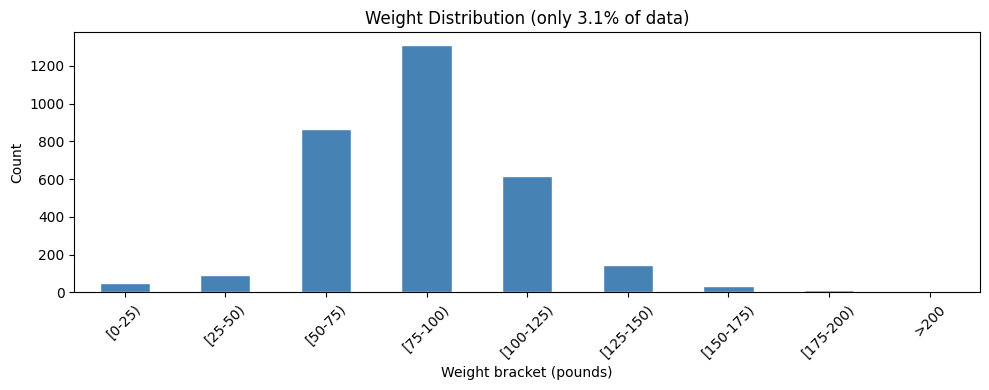

In [18]:
wt_avail = df["weight"].notna().sum()
wt_miss = df["weight"].isna().sum()
print("weight:")
print(f"  Available: {wt_avail:,} ({wt_avail / len(df) * 100:.2f}%)")
print(f"  Missing:   {wt_miss:,} ({wt_miss / len(df) * 100:.2f}%)")

# What does the available data look like?
if wt_avail > 0:
    # The UCI 130-hospitals weight column is a *string-coded* 25-pound bracket.
    # Treating it as a plain object dtype makes value_counts().sort_index()
    # sort alphabetically, so '[100-125)' lands between '[0-25)' and
    # '[25-50)' and the histogram's "shape" is unreadable. Cast to an ordered
    # pd.Categorical with the explicit numeric order before plotting.
    WEIGHT_BRACKETS_ORDER = [
        "[0-25)", "[25-50)", "[50-75)", "[75-100)",
        "[100-125)", "[125-150)", "[150-175)", "[175-200)", ">200",
    ]
    weight_ordered = pd.Categorical(
        df["weight"].dropna(),
        categories=WEIGHT_BRACKETS_ORDER,
        ordered=True,
    )

    print(f"\nDistribution of the {wt_avail:,} available values:")
    counts = pd.Series(weight_ordered).value_counts().reindex(WEIGHT_BRACKETS_ORDER, fill_value=0)
    print(counts)

    fig, ax = plt.subplots(figsize=(10, 4))
    counts.plot.bar(ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Weight Distribution (only {wt_avail / len(df) * 100:.1f}% of data)")
    ax.set_ylabel("Count")
    ax.set_xlabel("Weight bracket (pounds)")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


In [19]:
# Is the missingness random, or is it concentrated in certain groups?
print("Weight availability by readmission status:")
wt_by_readm = df.groupby("readmitted")["weight"].apply(lambda x: x.notna().mean() * 100)
for status, pct in wt_by_readm.items():
    print(f"  {status}: {pct:.2f}% have weight recorded")

print("\nWeight availability by age group (top 5):")
wt_by_age = df.groupby("age")["weight"].apply(lambda x: x.notna().mean() * 100).sort_values(ascending=False)
for age_grp, pct in wt_by_age.head(5).items():
    print(f"  {age_grp}: {pct:.2f}%")

Weight availability by readmission status:
  <30: 3.15% have weight recorded
  >30: 4.25% have weight recorded
  NO: 2.40% have weight recorded

Weight availability by age group (top 5):
  [20-30): 4.18%
  [70-80): 3.62%
  [60-70): 3.22%
  [80-90): 3.13%
  [0-10): 3.12%


**Finding.** Weight is recorded for only about 3% of encounters. The available data is in 25-pound brackets per the dataset documentation, and even those brackets are imprecise measurements. Missingness does not vary meaningfully across readmission groups or ages. It appears to be a hospital-level recording practice rather than a clinically selective process.

**Why this cannot be fixed.**

* **97% missing is beyond any imputation strategy.** Even the best imputation method would be inventing data for 97% of the column based on 3% of observations. The result would be dominated by imputation noise rather than real signal.
* **Bracketed values** (for example, [75-100)) are already low-resolution. Combined with 97% missingness, the information content is near zero.
* We cannot go back to the hospitals and retroactively collect weights from the 1999–2008 period.

**Why we do not impute.** Multiple imputation of the 97% missing weights conditional on age and diagnosis is theoretically possible using tools like `miceforest` or `IterativeImputer`. However, this would inject 30 times more imputed values than observed values into the feature. The resulting column would be variance-dominated by the imputation model rather than the data. Any downstream model would effectively be training on the imputer's structure rather than the patient signal. We reject imputation as variance-dominated and keep only the binary "weight was recorded" indicator engineered in §2.6.6. The *fact* of recording is informative even when the value is missing.

**Decision.** Drop the numeric column. Engineer `weight_recorded` indicator in §2.6.6.

**Bias caveat for the `weight_recorded` indicator.** Hospital-level recording practices for `weight` are typically correlated with payer mix and patient demographics, so the binary `weight_recorded` indicator can itself encode a hospital-level (and therefore population-level) recording bias. This is flagged as future work in the notebook 8 model card: before `weight_recorded` is admitted as a model feature on a real cohort, it must be cross-checked for per-subgroup association in an indirect-discrimination proxy audit. The model card discloses the limitation, and the audit itself is out of scope for the current bundle.


### 2.6.3 Medication Columns: Zero-Variance Scan

**What we are scanning.** The 23 categorical medication columns each record `No`, `Steady`, `Up`, or `Down`. If a medication was never prescribed in any encounter, its column is constant `"No"` with zero variance and carries no information.

**Why a 99% threshold rather than 100%.** Strictly zero-variance columns are obvious to drop. Near-zero-variance columns (where 99% of rows take the same value) are also drops, because after one-hot encoding they contribute a handful of sparse features that almost never fire. A 99% threshold is the project-wide constant used in `helpers/constants.py`. The scan reports both bands, so the decision is auditable.


In [20]:
med_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "acetohexamide", "glipizide", "glyburide",
    "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
    "miglitol", "troglitazone", "tolazamide", "examide", "citoglipton",
    "insulin", "glyburide-metformin", "glipizide-metformin",
    "glimepiride-pioglitazone", "metformin-rosiglitazone",
    "metformin-pioglitazone"
]

# Two thresholds:
#   - constant: exactly 1 unique value -> MUST drop (zero variance)
#   - near-constant: >=99% of rows take the same value -> drop (one-hot noise only)
NEAR_CONSTANT_THRESHOLD = 0.99

print(f"Scanning {len(med_cols)} medication columns...\n")
print(f"{'Column':<28s} {'Unique':>6s} {'% Prescribed':>13s} {'Top freq':>9s}  Status")
print("-" * 78)

constant_meds = []  # unique == 1
near_constant_meds = []  # top value frequency >= 0.99 (includes the constants)
for col in med_cols:
    nuniq = df[col].nunique()
    top_freq = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    pct_prescribed = (df[col] != "No").mean() * 100
    status = "OK"
    if nuniq == 1:
        status = "*** CONSTANT - zero variance ***"
        constant_meds.append(col)
        near_constant_meds.append(col)
    elif top_freq >= NEAR_CONSTANT_THRESHOLD:
        status = f"*** NEAR-CONSTANT ({top_freq:.2%}) ***"
        near_constant_meds.append(col)
    print(f"  {col:<26s} {nuniq:>6d} {pct_prescribed:>12.3f}% {top_freq:>8.2%}  {status}")

print(f"\nConstant      (zero variance):      {constant_meds}")
print(f"Near-constant (>={NEAR_CONSTANT_THRESHOLD:.0%} one value): {near_constant_meds}")


Scanning 23 medication columns...

Column                       Unique  % Prescribed  Top freq  Status
------------------------------------------------------------------------------


  metformin                       4       19.975%   80.03%  OK
  repaglinide                     4        1.528%   98.47%  OK
  nateglinide                     4        0.694%   99.31%  *** NEAR-CONSTANT (99.31%) ***
  chlorpropamide                  4        0.086%   99.91%  *** NEAR-CONSTANT (99.91%) ***
  glimepiride                     4        5.156%   94.84%  OK
  acetohexamide                   2        0.001%  100.00%  *** NEAR-CONSTANT (100.00%) ***
  glipizide                       4       12.613%   87.39%  OK
  glyburide                       4       10.593%   89.41%  OK
  tolbutamide                     2        0.021%   99.98%  *** NEAR-CONSTANT (99.98%) ***
  pioglitazone                    4        7.302%   92.70%  OK


  rosiglitazone                   4        6.345%   93.66%  OK
  acarbose                        4        0.307%   99.69%  *** NEAR-CONSTANT (99.69%) ***


  miglitol                        4        0.038%   99.96%  *** NEAR-CONSTANT (99.96%) ***
  troglitazone                    2        0.003%  100.00%  *** NEAR-CONSTANT (100.00%) ***
  tolazamide                      3        0.039%   99.96%  *** NEAR-CONSTANT (99.96%) ***


  examide                         1        0.000%  100.00%  *** CONSTANT - zero variance ***
  citoglipton                     1        0.000%  100.00%  *** CONSTANT - zero variance ***
  insulin                         4       53.316%   46.68%  OK
  glyburide-metformin             4        0.703%   99.30%  *** NEAR-CONSTANT (99.30%) ***
  glipizide-metformin             2        0.013%   99.99%  *** NEAR-CONSTANT (99.99%) ***
  glimepiride-pioglitazone        2        0.001%  100.00%  *** NEAR-CONSTANT (100.00%) ***
  metformin-rosiglitazone         2        0.002%  100.00%  *** NEAR-CONSTANT (100.00%) ***
  metformin-pioglitazone          2        0.001%  100.00%  *** NEAR-CONSTANT (100.00%) ***

Constant      (zero variance):      ['examide', 'citoglipton']
Near-constant (>=99% one value): ['nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'gli

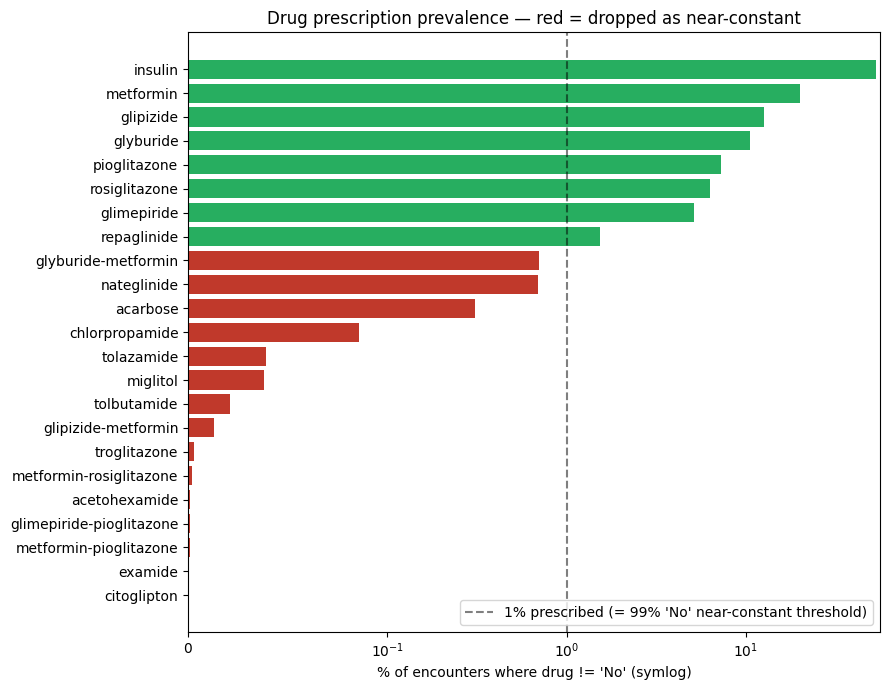

Dropped (red): 15 drugs. Kept (green): 8 drugs.


In [21]:
# Visualize % prescribed across all drug columns with the near-constant threshold marked
_prescribed_pct = pd.Series(
    {_c: (df[_c] != "No").mean() * 100 for _c in med_cols}
).sort_values()

_colors = [
    "#c0392b" if _c in near_constant_meds else "#27ae60"
    for _c in _prescribed_pct.index
]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(_prescribed_pct.index, _prescribed_pct.values, color=_colors)
ax.axvline(1.0, ls="--", color="black", alpha=0.5,
           label="1% prescribed (= 99% 'No' near-constant threshold)")
ax.set_xscale("symlog", linthresh=0.1)
ax.set_xlabel("% of encounters where drug != 'No' (symlog)")
ax.set_title("Drug prescription prevalence — red = dropped as near-constant")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()
print(f"Dropped (red): {len(near_constant_meds)} drugs. Kept (green): {len(med_cols) - len(near_constant_meds)} drugs.")


In [22]:
# Show the full value distribution for each near-constant drug column
for col in near_constant_meds:
    vc = df[col].value_counts(dropna=False)
    print(f"{col}:  {vc.to_dict()}")


nateglinide:  {'No': 98651, 'Steady': 654, 'Up': 24, 'Down': 11}
chlorpropamide:  {'No': 99255, 'Steady': 78, 'Up': 6, 'Down': 1}
acetohexamide:  {'No': 99339, 'Steady': 1}
tolbutamide:  {'No': 99319, 'Steady': 21}
acarbose:  {'No': 99035, 'Steady': 292, 'Up': 10, 'Down': 3}
miglitol:  {'No': 99302, 'Steady': 31, 'Down': 5, 'Up': 2}
troglitazone:  {'No': 99337, 'Steady': 3}
tolazamide:  {'No': 99301, 'Steady': 38, 'Up': 1}
examide:  {'No': 99340}
citoglipton:  {'No': 99340}
glyburide-metformin:  {'No': 98642, 'Steady': 684, 'Up': 8, 'Down': 6}
glipizide-metformin:  {'No': 99327, 'Steady': 13}
glimepiride-pioglitazone:  {'No': 99339, 'Steady': 1}
metformin-rosiglitazone:  {'No': 99338, 'Steady': 2}
metformin-pioglitazone:  {'No': 99339, 'Steady': 1}


**Findings.**

* **Strictly constant (two columns).** `examide` and `citoglipton` are `"No"` on every row. These drugs were never prescribed in the entire cohort, so the columns carry zero variance and therefore zero information.
* **Near-constant (additional columns).** Several more drug columns sit at or above the 99% same-value threshold. After one-hot encoding they contribute a handful of sparse features that almost never fire. More dimensionality, no signal.

**Why these cannot be fixed.**

* A feature with zero or near-zero variance cannot distinguish between readmitted and non-readmitted patients because every (or nearly every) patient has the same value.
* This reflects the clinical reality that these drugs were rarely or never used in these hospitals during 1999–2008, not a data-quality bug.
* No transformation (encoding, binning, imputation) can extract signal from a column where 99% or more of rows are the same value.

**Decision.** Drop every column in `near_constant_meds` (the live list is recomputed each run from the 99% threshold). The remaining surviving drugs (metformin, insulin, glipizide, glyburide, pioglitazone, rosiglitazone) carry enough variation to be useful. Notebook 4 §4.9's `*_taking` sidecar flags only cover the four highest-prevalence survivors. Pioglitazone and rosiglitazone are kept categorical only because their prevalence is too low for a useful binary "on this drug" indicator after the §2.10 stricter threshold.


### 2.6.4 `patient_nbr`: Group Leakage Risk (keep, do not drop)

**What we are quantifying.** The extent to which the same patient appears in multiple encounters. We also quantify the leakage that would result if a naive row-level random split were used downstream.

**Why this column is kept despite being an identifier.** Unlike `encounter_id`, `patient_nbr` is the *group key* for train/test splitting. The raw dataset has more rows than unique patients, which means a naive random split places the same patient in both train and test. A model under that split does not learn clinical patterns. It learns to recognize individual patients. Test metrics go up, real-world generalization goes down.


In [23]:
# Quantify the leakage risk
n_rows = len(df)
n_patients = df["patient_nbr"].nunique()
vc = df["patient_nbr"].value_counts()

print(f"rows:                        {n_rows:,}")
print(f"unique patients:             {n_patients:,}")
print(f"patients with >1 encounter:  {(vc > 1).sum():,}")
print(f"max encounters per patient:  {vc.max()}")

# Demonstrate the leak under a naive random split (uses SEED for bit-identical audit logs).
from sklearn.model_selection import train_test_split
from helpers.constants import SEED

tr, te = train_test_split(df, test_size=0.2, random_state=SEED)
leaked = set(tr["patient_nbr"]) & set(te["patient_nbr"])
print(f"\npatients leaking across a naive 80/20 split: {len(leaked):,}")


rows:                        99,340
unique patients:             69,987
patients with >1 encounter:  16,341
max encounters per patient:  40



patients leaking across a naive 80/20 split: 6,805


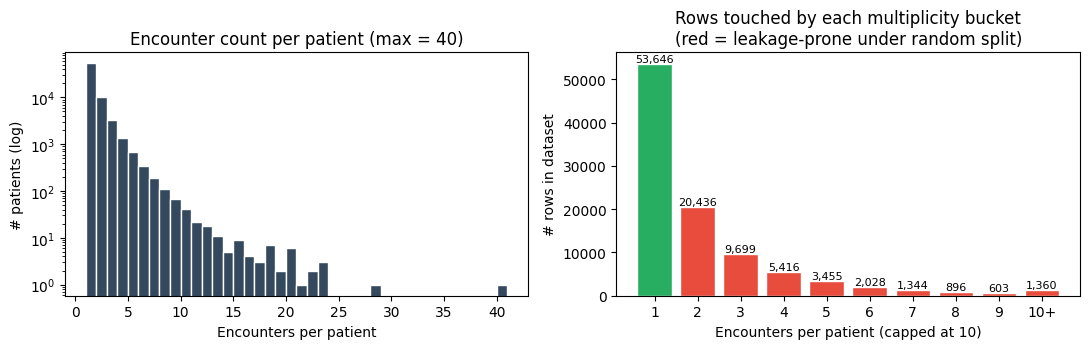

In [24]:
# Visualize encounters-per-patient: the long tail is the leakage surface
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

_enc_per_pt = vc.values
axes[0].hist(_enc_per_pt, bins=range(1, _enc_per_pt.max() + 2),
             color="#34495e", edgecolor="white", log=True)
axes[0].set_xlabel("Encounters per patient")
axes[0].set_ylabel("# patients (log)")
axes[0].set_title(f"Encounter count per patient (max = {_enc_per_pt.max()})")

# How many ROWS does each multiplicity bucket account for?
_bucket = (
    pd.Series(_enc_per_pt)
    .clip(upper=10)
    .value_counts()
    .sort_index()
)
_rows_in_bucket = (_bucket.index * _bucket.values)
_labels = [str(_i) if _i < 10 else "10+" for _i in _bucket.index]
_bar_colors = ["#27ae60"] + ["#e74c3c"] * (len(_labels) - 1)
axes[1].bar(_labels, _rows_in_bucket, color=_bar_colors, edgecolor="white")
axes[1].set_xlabel("Encounters per patient (capped at 10)")
axes[1].set_ylabel("# rows in dataset")
axes[1].set_title("Rows touched by each multiplicity bucket\n(red = leakage-prone under random split)")
for _x, _y in zip(_labels, _rows_in_bucket):
    axes[1].text(_x, _y, f"{_y:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()


**Finding.** Thousands of patients appear in multiple encounters, and a naive random split puts most of them on both sides of the train/test boundary. This is the single largest leakage risk in the dataset.

**Decision.** Keep `patient_nbr` in the cleaned CSV. It is excluded from the feature matrix in notebook 4 but used as the group key in downstream sections. All train/test splits in notebook 5 and beyond **must** use `GroupKFold` or `GroupShuffleSplit` on `patient_nbr`, or deduplicate to one encounter per patient first. This is non-negotiable. A random split on this dataset produces invalid metrics that look excellent in development and collapse in deployment.

**Replayed downstream as a regression test.** Notebook 5's §5.4 split discipline replays this exact diagnostic on the patient-grouped split it constructs, so the reader sees the leaked-patient count drop from this non-zero baseline to zero between the two notebooks.

**Structural, not seed-sensitive.** The leaked-patient count above is driven by repeated `patient_nbr` values rather than the random seed, so the diagnostic replays bit-for-bit on any re-run. We still pass the project-wide `SEED` only so audit logs are byte-identical.


### 2.6.5 `diabetesMed` vs. Individual Drug Columns: Redundancy Check

**What we are testing.** Whether `diabetesMed` (a single yes/no summary) is an exact deterministic function of the 23 individual drug columns. If it is, keeping both forces downstream models to deal with perfect collinearity, which destabilizes linear models and wastes splits in tree models.

**Why this check is more than a hygiene exercise.** Perfect collinearity is silently fatal in two of our model families. Logistic regression's coefficient estimates become unstable, with one coefficient swinging by a large amount whenever the redundant column flips. Tree ensembles do not crash, but every split that uses the summary column is a wasted opportunity to split on a more informative feature.


In [25]:
# Is diabetesMed a deterministic function of the drug columns?
all_drug_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "acetohexamide", "glipizide", "glyburide",
    "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
    "miglitol", "troglitazone", "tolazamide", "examide", "citoglipton",
    "insulin", "glyburide-metformin", "glipizide-metformin",
    "glimepiride-pioglitazone", "metformin-rosiglitazone",
    "metformin-pioglitazone",
]
any_drug = (df[all_drug_cols] != "No").any(axis=1)
agree = (any_drug == (df["diabetesMed"] == "Yes")).mean()
print(f"diabetesMed agrees with (any drug != 'No'): {agree:.6f}")
print("\nCross-tab:")
print(pd.crosstab(df["diabetesMed"], any_drug, rownames=['diabetesMed'], colnames=['any_drug != No']))


diabetesMed agrees with (any drug != 'No'): 1.000000

Cross-tab:
any_drug != No  False  True 
diabetesMed                 
No              22623      0
Yes                 0  76717


**Finding.** `diabetesMed` is a perfect deterministic function of the 23 drug columns. It adds zero information given the drug columns but introduces perfect collinearity that destabilises linear and logistic models and wastes a split in tree models.

**Decision.** Drop `diabetesMed`. We keep the per-drug columns because they carry the fine-grained signal (steady, up, down, no). Downstream models that want a simple "any diabetes med" feature can reconstruct it in one line.


### 2.6.6 Execute the Column Drops

**What we are doing.** Applying every drop decision from §2.6.1 through §2.6.5 in a single transaction. Before dropping `weight`, we engineer the binary `weight_recorded` indicator so the signal survives even when the numeric value does not.

**Why preserve a "was recorded" indicator.** Hospital-level variation in recording practices is itself informative. A hospital that records weights on most encounters has a different documentation discipline than one that records weights almost never, and that discipline correlates with other quality-of-care indicators. The numeric value is unrecoverable, but the *presence* of the value is salvageable.


In [26]:
# Preserve the binary "weight was recorded" signal before dropping the column.
df["weight_recorded"] = df["weight"].notna().astype(int)
print(f"weight_recorded: {df['weight_recorded'].sum():,} rows ({df['weight_recorded'].mean() * 100:.2f}%)")


weight_recorded: 3,125 rows (3.15%)


In [27]:
# ACTION: Drop the identified columns
#   - encounter_id: unique row identifier, not a feature
#   - weight: 97% missing (weight_recorded indicator preserved above)
#   - near_constant_meds: 17 drug columns with zero / near-zero variance (incl. examide, citoglipton)
#   - diabetesMed: deterministic function of the drug columns (perfect collinearity)
drop_cols = ["encounter_id", "weight"] + near_constant_meds + ["diabetesMed"]
print("Dropping columns:")
for col in drop_cols:
    print(f"  {col}")

df = df.drop(columns=drop_cols)
print(f"\nShape after: {df.shape}")


Dropping columns:
  encounter_id
  weight
  nateglinide
  chlorpropamide
  acetohexamide
  tolbutamide
  acarbose
  miglitol
  troglitazone
  tolazamide
  examide
  citoglipton
  glyburide-metformin
  glipizide-metformin
  glimepiride-pioglitazone
  metformin-rosiglitazone
  metformin-pioglitazone
  diabetesMed

Shape after: (99340, 33)


**Result.** Encounter ID, weight, the near-constant drug columns, and `diabetesMed` are gone. The `weight_recorded` indicator survives. The dataframe shape printed above is the post-drop state.


## 2.7 Missing-Value Triage by Cause

**What we are differentiating.** Three categorically different types of missingness, each requiring a different intervention:

| Type | What it means | Correct intervention |
|---|---|---|
| **Random gaps** | The value exists but was not recorded due to administrative variation | Fill with `"Unknown"` to preserve the row |
| **Systematic missingness** | The value is structurally absent for a subgroup (a specialty was never recorded by a particular hospital) | Fill with `"Unknown"` and treat as its own category |
| **Informative missingness** | The absence of the value IS the signal (a lab test was not ordered because the clinician was not concerned) | Keep as `NaN` and encode as a "test ordered" flag in §4 |

**Why this section is the single most consequential cleaning decision.** Treating informative missingness as a random gap and mode-imputing it destroys the signal entirely. Treating a random gap as informative missingness creates noise. Getting this distinction right per column is what separates a clean cohort from one that silently contaminates every downstream metric.


In [28]:
# Current missing values after row/column drops
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Remaining columns with missing values:")
for col, cnt in missing.items():
    print(f"  {col}: {cnt:,} ({cnt / len(df) * 100:.2f}%)")

Remaining columns with missing values:
  max_glu_serum: 94,188 (94.81%)
  A1Cresult: 82,506 (83.05%)
  medical_specialty: 48,614 (48.94%)
  payer_code: 39,397 (39.66%)
  admission_type_id: 10,144 (10.21%)
  admission_source_id: 6,854 (6.90%)
  discharge_disposition_id: 4,680 (4.71%)
  race: 2,232 (2.25%)
  diag_3: 1,419 (1.43%)
  diag_2: 356 (0.36%)
  diag_1: 20 (0.02%)


### 2.7.1 Lab Columns: `max_glu_serum` and `A1Cresult` (informative missingness)

**What we are investigating.** Whether the readmission rate differs between patients who *were* tested and patients who *were not* tested. If the rates differ, the testing decision itself carries a signal and must be preserved as a feature.

**The clinical logic.** If a doctor suspects poor glucose control, they order an HbA1c or glucose serum test. If they do not suspect a problem, they skip the test. The decision to test is itself a clinical judgment that carries information about the doctor's prior belief about patient risk. This differs from "data was lost".


In [29]:
# Demonstrate: is there a difference in readmission between tested and not-tested patients?
for col in ["max_glu_serum", "A1Cresult"]:
    tested = df[col].notna()
    print(f" {col} ")
    print(f"  Tested:     {tested.sum():,} ({tested.mean() * 100:.1f}%)")
    print(f"  Not tested: {(~tested).sum():,} ({(~tested).mean() * 100:.1f}%)")

    # Readmission rates for tested vs. not tested
    readm_tested = df[tested]["readmitted"].value_counts(normalize=True) * 100
    readm_not_tested = df[~tested]["readmitted"].value_counts(normalize=True) * 100

    print(
        f"  Readmission rates (tested):     NO={readm_tested.get('NO', 0):.1f}%, >30={readm_tested.get('>30', 0):.1f}%, <30={readm_tested.get('<30', 0):.1f}%")
    print(
        f"  Readmission rates (not tested): NO={readm_not_tested.get('NO', 0):.1f}%, >30={readm_not_tested.get('>30', 0):.1f}%, <30={readm_not_tested.get('<30', 0):.1f}%")
    print()

    # What results look like when the test WAS done
    print("  Results when tested:")
    print(f"  {df[col].value_counts().to_string()}")
    print()

 max_glu_serum 
  Tested:     5,152 (5.2%)
  Not tested: 94,188 (94.8%)
  Readmission rates (tested):     NO=49.7%, >30=37.6%, <30=12.8%
  Readmission rates (not tested): NO=53.0%, >30=35.6%, <30=11.3%

  Results when tested:
  max_glu_serum
Norm    2545
>200    1419
>300    1188

 A1Cresult 
  Tested:     16,834 (16.9%)
  Not tested: 82,506 (83.1%)
  Readmission rates (tested):     NO=55.6%, >30=34.4%, <30=9.9%
  Readmission rates (not tested): NO=52.3%, >30=36.0%, <30=11.7%

  Results when tested:
  A1Cresult
>8      8137
Norm    4922
>7      3775



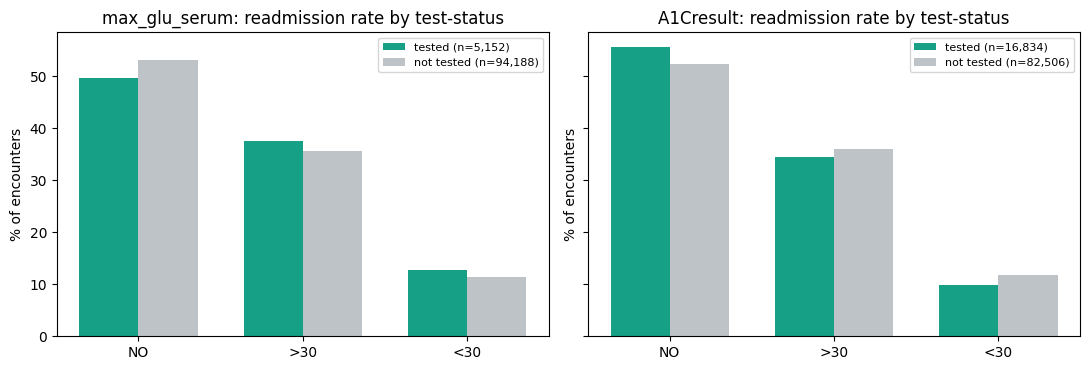

In [30]:
# Visualize the informative-missingness claim: readmission rates differ tested vs not-tested
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
_classes = ["NO", ">30", "<30"]
_class_colors = {"NO": "#7f8c8d", ">30": "#3498db", "<30": "#e74c3c"}

for _ax, _col in zip(axes, ["max_glu_serum", "A1Cresult"]):
    _tested = df[_col].notna()
    _rt = df[_tested]["readmitted"].value_counts(normalize=True) * 100
    _rn = df[~_tested]["readmitted"].value_counts(normalize=True) * 100
    _x = np.arange(len(_classes))
    _w = 0.36
    _ax.bar(_x - _w / 2, [_rt.get(_c, 0) for _c in _classes], _w,
            label=f"tested (n={_tested.sum():,})", color="#16a085")
    _ax.bar(_x + _w / 2, [_rn.get(_c, 0) for _c in _classes], _w,
            label=f"not tested (n={(~_tested).sum():,})", color="#bdc3c7")
    _ax.set_xticks(_x)
    _ax.set_xticklabels(_classes)
    _ax.set_ylabel("% of encounters")
    _ax.set_title(f"{_col}: readmission rate by test-status")
    _ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Finding.** The tested versus not-tested groups have measurably different readmission profiles, confirming that the testing decision carries a signal.

**Why these cannot be filled with a value.**

* These are not "missing" in the traditional sense. They represent "test not performed". Imputing a glucose level or A1C result for a patient who was never tested would fabricate clinical data.
* Filling with the mode or median would mask the useful tested-versus-not-tested distinction.
* The correct encoding (binary `was_tested` plus result when available) is done in §4 feature engineering.

**Decision.** Keep as `NaN`. The `A1C_measured` and `glu_measured` flags are derived in §2.10, and §4 encodes the result with `not_measured` as an explicit category.


### 2.7.2 Categorical Columns: `race`, `payer_code`, `medical_specialty`, `diag_1/2/3`

**What we are deciding.** Per-column fill strategy for genuinely missing values. For each column we assess whether the missingness is random or systematic, and whether imputation would be appropriate.

**Why `"Unknown"` rather than mode imputation, every time.** Filling with the most common value fabricates data that looks real but is not, and biases every downstream analysis towards the modal category. `"Unknown"` is transparent. It tells downstream models "we do not know this value" and lets them learn from that fact rather than from a lie. The cost is one extra one-hot column per filled feature, which is a tiny price for honesty.

**Two different reasons for the same fill rule.** The MCAR-like columns and the MNAR columns both end up as `"Unknown"`, but for different reasons.

* **MCAR-like (trace missing) columns: `race`, `diag_1`, `diag_2`, `diag_3`.** Missingness is so small that the choice of fill barely moves any downstream statistic. `"Unknown"` here is hygiene: it keeps the categorical encoder from choking on NaN, and it does not pretend to know a value we do not have. There is little informative signal in *being* missing because the missing share is too small to anchor a learnable split.
* **MNAR (large missing share) columns: `medical_specialty` (~50%), `payer_code` (~40%).** The missing share is large and almost certainly systematic. Certain hospitals or departments simply do not record these fields. Here `"Unknown"` is itself a feature, not just hygiene: mode imputation would erase a real, learnable pattern about *which encounters get recorded and which do not*. §2.10's second pass therefore derives explicit `medical_specialty_missing` and `payer_code_missing` indicator columns so that tree models can split directly on the missingness signal rather than having to recover it from a high-cardinality category.

In [31]:
cat_missing = ["race", "payer_code", "medical_specialty", "diag_1", "diag_2", "diag_3"]

for col in cat_missing:
    n_miss = df[col].isna().sum()
    if n_miss == 0:
        continue
    pct = n_miss / len(df) * 100
    print(f"=== {col} ({pct:.2f}% missing) ===")

    # Distribution of non-missing values
    vc = df[col].value_counts()
    print(f"  Top 5 values (of {df[col].nunique()} unique):")
    for val, cnt in vc.head(5).items():
        print(f"    {val}: {cnt:,} ({cnt / len(df) * 100:.1f}%)")

    # Is readmission different for missing vs non-missing?
    has_val = df[col].notna()
    r_has = df[has_val]["readmitted"].value_counts(normalize=True).get("<30", 0) * 100
    r_miss = df[~has_val]["readmitted"].value_counts(normalize=True).get("<30", 0) * 100
    print(f"  <30-day readmission: has value = {r_has:.1f}%, missing = {r_miss:.1f}%")
    print()

=== race (2.25% missing) ===
  Top 5 values (of 5 unique):
    Caucasian: 74,220 (74.7%)
    AfricanAmerican: 18,772 (18.9%)
    Hispanic: 2,017 (2.0%)
    Other: 1,471 (1.5%)
    Asian: 628 (0.6%)


  <30-day readmission: has value = 11.5%, missing = 8.4%



=== payer_code (39.66% missing) ===
  Top 5 values (of 17 unique):
    MC: 31,333 (31.5%)
    HM: 6,195 (6.2%)
    SP: 4,941 (5.0%)
    BC: 4,601 (4.6%)
    MD: 3,473 (3.5%)
  <30-day readmission: has value = 11.2%, missing = 11.7%

=== medical_specialty (48.94% missing) ===
  Top 5 values (of 72 unique):
    InternalMedicine: 14,237 (14.3%)
    Emergency/Trauma: 7,419 (7.5%)
    Family/GeneralPractice: 7,252 (7.3%)
    Cardiology: 5,278 (5.3%)
    Surgery-General: 3,059 (3.1%)
  <30-day readmission: has value = 11.0%, missing = 11.8%

=== diag_1 (0.02% missing) ===
  Top 5 values (of 715 unique):
    428: 6,663 (6.7%)
    414: 6,549 (6.6%)
    786: 4,015 (4.0%)
    410: 3,448 (3.5%)
    486: 3,383 (3.4%)


  <30-day readmission: has value = 11.4%, missing = 25.0%

=== diag_2 (0.36% missing) ===
  Top 5 values (of 747 unique):
    276: 6,589 (6.6%)
    428: 6,459 (6.5%)
    250: 6,051 (6.1%)
    427: 4,892 (4.9%)
    401: 3,722 (3.7%)
  <30-day readmission: has value = 11.4%, missing = 8.1%

=== diag_3 (1.43% missing) ===
  Top 5 values (of 786 unique):
    250: 11,466 (11.5%)
    401: 8,240 (8.3%)
    276: 4,953 (5.0%)
    428: 4,412 (4.4%)
    427: 3,785 (3.8%)
  <30-day readmission: has value = 11.5%, missing = 6.4%



**Analysis by column.**

**`race`** (trace missing). The dominant value is Caucasian, so the mode of imputation would be heavily biased. The missing share is too small to distort downstream analysis. Decision: fill with `"Unknown"`.

**`payer_code`** (large missing share). Insurance type is a socioeconomic proxy. The missing share is large and almost certainly not random. Certain hospitals or encounter types do not record payer. Mode imputation would assign the most common insurance to a large slice of encounters, creating a massive bias. The "not recorded" status may itself be informative because it correlates with hospital practices. Decision: fill with `"Unknown"`.

**`medical_specialty`** (about half missing). Roughly half the data is missing. This is almost certainly systematic. Certain hospitals or departments do not record physicians' specialties. Imputation is impossible when half the data is missing. Any imputed distribution would be invented. Decision: fill with `"Unknown"`, which preserves the systematic "not recorded" pattern as its own category.

**`diag_1/2/3`** (trace missing). Very few missing diagnoses. These are likely administrative gaps (patient transferred before diagnosis was finalized, for instance). With such a small missing share, the impact of any fill strategy is negligible. Decision: fill with `"Unknown"`.

**The principle behind every "Unknown" decision.** Transparency over fabrication. Filling with mode invents data. Filling with `"Unknown"` admits ignorance and lets the model decide whether the missingness itself carries a signal.

**Forward fairness-audit hook for `payer_code`.** Because `payer_code` is a socioeconomic proxy and not a random missing-completely-at-random column, it enters `X` as a feature and is registered in `helpers/fairness.PROTECTED_ATTRIBUTE_COLUMNS`. The §8 model card should therefore report recall by payer group in addition to the conventional race / sex / age axes, so subgroup performance on the insurance proxy is auditable rather than implicit.


In [32]:
fill_cols = {
    "race": "Unknown",
    "payer_code": "Unknown",
    "medical_specialty": "Unknown",
    "diag_1": "Unknown",
    "diag_2": "Unknown",
    "diag_3": "Unknown",
}

for col, fill_val in fill_cols.items():
    n_miss = df[col].isna().sum()
    if n_miss > 0:
        print(f"  {col}: {n_miss:,} NaN -> '{fill_val}'")
        df[col] = df[col].fillna(fill_val)

# Verify
print("\nRemaining missing values (lab results plus admin sentinel-converted columns):")
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
if len(remaining) == 0:
    print("  None")
else:
    for col, cnt in remaining.items():
        print(f"  {col}: {cnt:,} ({cnt / len(df) * 100:.1f}%) - intentionally preserved")

  race: 2,232 NaN -> 'Unknown'
  payer_code: 39,397 NaN -> 'Unknown'
  medical_specialty: 48,614 NaN -> 'Unknown'
  diag_1: 20 NaN -> 'Unknown'
  diag_2: 356 NaN -> 'Unknown'
  diag_3: 1,419 NaN -> 'Unknown'

Remaining missing values (lab results plus admin sentinel-converted columns):
  admission_type_id: 10,144 (10.2%) - intentionally preserved
  discharge_disposition_id: 4,680 (4.7%) - intentionally preserved
  admission_source_id: 6,854 (6.9%) - intentionally preserved
  max_glu_serum: 94,188 (94.8%) - intentionally preserved
  A1Cresult: 82,506 (83.1%) - intentionally preserved


## 2.8 Verify and Save

**What we are doing.** Printing the final shape, type composition, and target distribution, then writing the cleaned table to `data/cleaned.csv`.

**Why a final verification print matters.** Cleaning bugs that pass the in-section checks (a fillna applied to the wrong column, a row filter that accidentally inverted the mask) only show up when the *final* shape and target distribution are compared against the expectations the audit established at §2.3. The print below is the last opportunity to catch a regression before the CSV ships to downstream notebooks.


In [33]:
print(f"Final shape: {df.shape}")
print("\nColumn types:")
print(df.dtypes.value_counts())
print("\nTarget distribution (after cleaning):")
vc = df["readmitted"].value_counts()
for val, cnt in vc.items():
    print(f"  {val}: {cnt:,} ({cnt / len(df) * 100:.1f}%)")
print("\nSample:")
df.head(3)

Final shape: (99340, 33)

Column types:
object     20
int64      10
float64     3
Name: count, dtype: int64

Target distribution (after cleaning):
  NO: 52,524 (52.9%)
  >30: 35,502 (35.7%)
  <30: 11,314 (11.4%)

Sample:


,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,repaglinide,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin,change,readmitted,weight_recorded
0,8222157,Caucasian,Female,[0-10),NaN,NaN,1.0,1,Unknown,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,NO,0
1,55629189,Caucasian,Female,[10-20),1.0,1.0,7.0,3,Unknown,Unknown,...,No,No,No,No,No,No,Up,Ch,>30,0
2,86047875,AfricanAmerican,Female,[20-30),1.0,1.0,7.0,2,Unknown,Unknown,...,No,No,Steady,No,No,No,No,No,NO,0


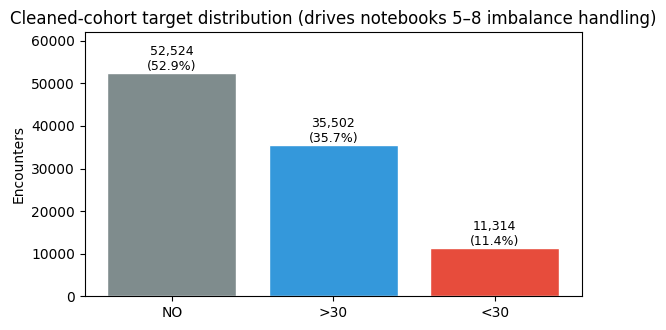

In [34]:
# Visualize the cleaned-cohort target distribution: the imbalance baseline downstream metrics anchor to
_tgt = df["readmitted"].value_counts().reindex(["NO", ">30", "<30"])
_pct = (_tgt / _tgt.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(6, 3.4))
_bars = ax.bar(_tgt.index, _tgt.values,
               color=["#7f8c8d", "#3498db", "#e74c3c"], edgecolor="white")
ax.set_ylabel("Encounters")
ax.set_title("Cleaned-cohort target distribution (drives notebooks 5–8 imbalance handling)")
for _b, _n, _p in zip(_bars, _tgt.values, _pct.values):
    ax.text(_b.get_x() + _b.get_width() / 2, _n,
            f"{_n:,}\n({_p:.1f}%)", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, _tgt.max() * 1.18)
plt.tight_layout()
plt.show()


In [35]:
import os

os.makedirs("../data", exist_ok=True)
df.to_csv("../data/cleaned.csv", index=False, na_rep="")  # nan-token-string-in-raw-csv guard
print("Saved: ../data/cleaned.csv")
print(f"  {len(df):,} rows x {df.shape[1]} columns")

Saved: ../data/cleaned.csv
  99,340 rows x 33 columns


**Reading the final verification.** The row count printed above is the cleaned cohort that the rest of the pipeline operates on. The target distribution drives every imbalance-aware decision downstream: the class weighting in notebook 6, the threshold sweep in notebook 6's §6.8, and the AUC-PR baseline in notebook 8. Recording it explicitly here means a future reader can reconstruct the "why" behind any downstream metric without re-running this notebook.


## 2.9 Summary of All Cleaning Actions

**Purpose of this table.** A consolidated audit log of every cleaning decision in §2.4 through §2.8. Anyone challenging or replicating the cleaning pass can use this table as the index and read back into the relevant subsection for the supporting analysis.

| #  | Issue Found                                                                                        | Decision and Why                                                                                                                                                   | Impact                                                                          |
|----|----------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------|
| 1  | Expired or hospice patients in `discharge_disposition_id`                                          | **Remove rows.** Codes 11, 13, 14, 19, 20, 21 map to death or hospice. Cross-tab confirms these patients are "NO" readmission by logical necessity.                | Small share of rows (count logged in §2.4)                                      |
| 2  | Integer NULL sentinels in `admission_type_id` / `discharge_disposition_id` / `admission_source_id` | **Map to NaN** (same logic as `?`). Codes {5, 6, 8}, {18, 25, 26}, {9, 15, 17, 20, 21} are documented as Not Available, NULL, or Not Mapped.                       | Sentinel values remapped (count logged in §2.4.1)                               |
| 3  | `gender = "Unknown/Invalid"`                                                                       | **Remove rows.** A handful of rows. No way to recover true gender.                                                                                                 | Rows removed (count logged in §2.5)                                             |
| 4  | `encounter_id` is a row-level unique ID                                                            | **Drop column.** `nunique == nrows`. No clinical meaning. Would overfit.                                                                                           | 1 column                                                                        |
| 5  | `weight` has 97% missing                                                                           | **Drop column**, keep `weight_recorded` indicator. Only 3% recorded, in coarse 25-pound brackets. Imputation cannot recover signal from 3%.                        | Minus 1 column, plus 1 column                                                   |
| 6  | Near-constant or zero-variance drug columns                                                        | **Drop columns.** `examide` and `citoglipton` are 100% `"No"`. Additional drug columns sit at or above the 99% near-constant threshold.                            | Multiple columns dropped (count logged in §2.6.6)                               |
| 7  | `diabetesMed` is a deterministic function of the drug columns                                      | **Drop column.** `(any drug != 'No') == (diabetesMed == 'Yes')` holds for every row.                                                                               | 1 column                                                                        |
| 8  | `patient_nbr` duplication leads to group leakage under random split                                | **Keep column, forbid random split.** Many patients appear in multiple encounters. A naive random split leaks the same patient across train and test.              | Contract for downstream notebooks                                               |
| 9  | Categorical NaN in `race`, `payer_code`, `medical_specialty`, `diag_1/2/3`                         | **Fill with `"Unknown"`.** Mode imputation would fabricate biased data, and missingness is often systematic.                                                       | Many values relabelled (counts logged in §2.7.2)                                |
| 10 | Lab NaN in `max_glu_serum`, `A1Cresult`                                                            | **Keep as NaN.** 95% and 83% missing. Missingness means "test not ordered", which is itself informative.                                                           | Encoded in §2.10 (MNAR indicators) and §4 (test-ordered flag)                    |

**Input.** Raw UCI extract (shape printed at the top of §2).
**Output.** Cleaned table written to `data/cleaned.csv` (final shape printed at the end of §2.8, then re-overwritten by the §2.10 and §2.11 passes that layer modelling-readiness corrections on top).

**Downstream contract** (enforced here, extended by §2.10, consumed by notebook 5):

1. `patient_nbr` is the group key for every train/test/CV split. **Never random-split this dataset.**
2. Lab columns `max_glu_serum` and `A1Cresult` carry NaN deliberately. Do not impute. §2.10 emits the `A1C_measured` and `glu_measured` MNAR indicators and refills the columns with `"not_measured"`. Feature engineering consumes those columns.
3. Diagnosis columns `diag_1/2/3` are filled with `"Unknown"` here, then rolled up to nine clinical chapters by §2.10 (the `diag_*_cat` columns are baked into `cleaned.csv`). Notebook 4 only consumes the chapter labels.


## 2.10 Modeling-Readiness Corrections (Second Pass)

**Why a second pass.** Sections 2.2 through 2.6 produce `cleaned.csv` for human readability and downstream EDA. Section 2.8 then applies modeling-readiness corrections on top: MNAR-indicator derivation (`*_missing` flags), label canonicalization, near-constant column drops driven by a stricter train-only threshold, ICD-9 rollup to clinical chapters, and `log1p` sidecars on heavy-tailed counts.

**Why a separate idempotent pass rather than inline edits.** The cell below is idempotent by design. It re-sources from a one-time snapshot at `cleaned_baseline.csv` (auto-created on first run). Consequently, re-running this cell produces the same output regardless of how many times `cleaned.csv` has been overwritten downstream. The §2.10 logic itself is split across narrow helpers in `helpers/clean_helpers.py`, each of which is named after the single transformation it performs, so the pipeline below reads as a linear composition.

**Why train-only thresholds.** Three of the rollup decisions (`drop_near_constant`, `rollup_icd9`, `rollup_specialty_top10`) depend on frequency thresholds that must be computed *only on the training partition* to avoid leakage. The cell builds the same patient-grouped train mask that notebook 5 derives, passes it to each helper, and computes thresholds on training rows alone.


In [36]:
# === Section 2.10: Modeling-Readiness Corrections (Second Pass) ===
# Reloads cleaned.csv from disk (independent of prior cell state), applies the
# corrections via narrow helpers in 'helpers/clean_helpers.py', and overwrites cleaned.csv.
# A sidecar 'cleaned_baseline.csv' preserves the pre-§2.8 baseline for reproducibility.
import shutil
from pathlib import Path
import pandas as pd

from helpers.clean_helpers import (
    restore_unknown_nans,
    derive_mnar_flags,
    derive_lab_measured_flags,
    refill_categorical_unknowns,
    canonicalize_admin_ids,
    canonicalize_label,
    drop_near_constant,
    rollup_icd9,
    rollup_specialty_top10,
    log1p_utilization,
    build_train_mask_for_rollup,
)

try:
    PROJECT_ROOT  # type: ignore[name-defined]
except NameError:
    PROJECT_ROOT = Path.cwd().resolve()
    if PROJECT_ROOT.name == "pipeline":
        PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
CLEANED = DATA_DIR / "cleaned.csv"
PREFIX = DATA_DIR / "cleaned_baseline.csv"

# Preserve the pre-§2.10 baseline once (idempotent).
if not PREFIX.exists():
    shutil.copy(CLEANED, PREFIX)

# Always re-source from the baseline so §2.10 is idempotent.
df = pd.read_csv(PREFIX, low_memory=False)
print(f"loaded cleaned_baseline.csv: {df.shape}")
n_before = len(df)

# Pipeline. Each helper is documented in 'helpers/clean_helpers.py'. The order matters:
# MNAR flags must be derived BEFORE the "Unknown" refill, since notna() cannot
# tell a real value from the literal string "Unknown".
# Build the same patient-grouped 70/10/20
# train mask NB05 will later derive and pass it to the three frequency-dependent rollup so
# the modal-share cutoff and top-K prefix / specialty choices are made on TRAIN rows only.
# Both pipelines build the mask from patient_nbr + the binary <30 target with random_state=42,
# so NB05's downstream split is unaffected: see helpers.clean_helpers.build_train_mask_for_rollups.
_train_mask = build_train_mask_for_rollup(df, seed=42)
print(f"  train_mask: {_train_mask.sum()} / {len(_train_mask)} rows on train side ({_train_mask.mean():.1%})")

df = (
    df
    .pipe(restore_unknown_nans)  # reverse §2.5.2's string fill so MNAR is computable
    .pipe(derive_mnar_flags)  # 0/1 indicators on race / payer_code / medical_specialty
    .pipe(derive_lab_measured_flags)  # A1C_measured / glu_measured + 'not_measured' fill
    .pipe(canonicalize_admin_ids)  # int NULL sentinels in admission_*/discharge_disposition_id → NaN
    .pipe(canonicalize_label)  # strip whitespace from 'readmitted'
    .pipe(refill_categorical_unknowns)  # restore "Unknown" string fill for human-readable CSV
    .pipe(drop_near_constant, train_mask=_train_mask)  # train-only modal-share cutoff
    .pipe(rollup_icd9, train_mask=_train_mask)  # train-only top-25 ICD-9 prefix choice
    .pipe(rollup_specialty_top10, train_mask=_train_mask)  # train-only top-10 specialty choice
    .pipe(log1p_utilization)  # logo + has_any flags on the 3 utilization counts
)
n_after = len(df)
print(f"§2.10 pipeline complete: {df.shape}  (rows {n_before} -> {n_after})")

# Overwrite cleaned.csv with the corrected dataset for downstream pipeline.
df.to_csv(CLEANED, index=False)
print(f"wrote cleaned.csv: {df.shape}")


loaded cleaned_baseline.csv: (99340, 33)
  train_mask: 69523 / 99340 rows on train side (70.0%)


§2.10 pipeline complete: (99340, 50)  (rows 99340 -> 99340)


wrote cleaned.csv: (99340, 50)


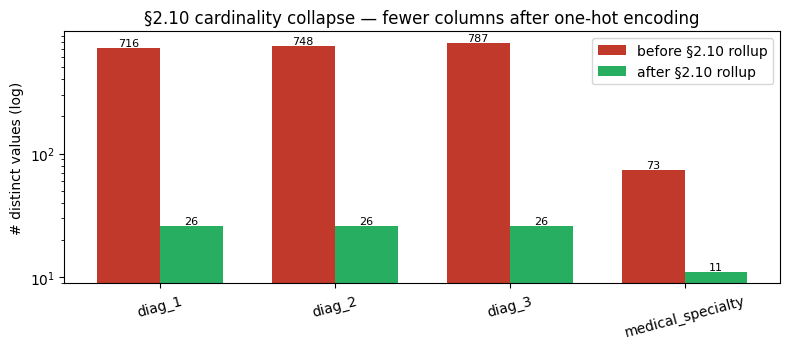

In [37]:
# Visualize the §2.10 cardinality collapse: ICD-9 codes -> 9 clinical chapters, specialties -> top-10 + Other
_raw = pd.read_csv(PREFIX, low_memory=False)  # the pre-§2.10 baseline saved above


def _rolled_name(col: str) -> str:
    """Return the post-rollup column name that helpers/clean_helpers.py actually emits.

    diag_*  -> diag_*_cat                       (rollup_icd9)
    medical_specialty -> medical_specialty_grouped  (rollup_specialty_top10)
    """
    if col.startswith("diag_"):
        return f"{col}_cat"
    if col == "medical_specialty":
        return "medical_specialty_grouped"
    return col


_before_after = {}
for _col in ["diag_1", "diag_2", "diag_3", "medical_specialty"]:
    _rolled_col = _rolled_name(_col)
    if _rolled_col not in df.columns:
        raise KeyError(
            f"§2.10 rollup did not emit expected column '{_rolled_col}'. "
            "Refusing to plot a misleading before/after that silently falls back "
            "to the un-rolled raw column."
        )
    _before_after[_col] = (
        _raw[_col].nunique(dropna=True),
        df[_rolled_col].nunique(dropna=True),
    )

fig, ax = plt.subplots(figsize=(8, 3.6))
_labels = list(_before_after.keys())
_x = np.arange(len(_labels))
_w = 0.36
_before = [_before_after[_l][0] for _l in _labels]
_after = [_before_after[_l][1] for _l in _labels]
ax.bar(_x - _w / 2, _before, _w, label="before §2.10 rollup", color="#c0392b")
ax.bar(_x + _w / 2, _after, _w, label="after §2.10 rollup", color="#27ae60")
ax.set_yscale("log")
ax.set_xticks(_x)
ax.set_xticklabels(_labels, rotation=15)
ax.set_ylabel("# distinct values (log)")
ax.set_title("§2.10 cardinality collapse — fewer columns after one-hot encoding")
for _i, (_b, _a) in enumerate(zip(_before, _after)):
    ax.text(_i - _w / 2, _b, str(_b), ha="center", va="bottom", fontsize=8)
    ax.text(_i + _w / 2, _a, str(_a), ha="center", va="bottom", fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()


**What §2.10 produced.** The dataframe shape printed above reflects the post-rollup state. The most consequential changes are the ICD-9 rollup (700 unique codes per diagnosis column collapse to nine clinical chapters), the specialty rollup (dozens of specialties collapse to a top-10 plus `"Other"`), and the MNAR indicators (one new column per heavily missing categorical, encoding "was this value originally missing").

**Why §2.10 sits *after* §2.9's audit table.** The audit table records the human-readable cleaning decisions. The §2.10 pass adds the model-only corrections that a future analyst would want to see as a *layered* operation rather than as another row in the audit table. Keeping the two passes structurally separate means you can read §2.9 to understand the *cohort* and read §2.10 to understand the *encoding*, without conflating the two.


## 2.11 Feature Additions: Drug-Taking Flags and Skewed-Count `log1p`

**What this section adds.** Two small but consequential feature additions on top of §2.10:

* **Drug-taking flags.** `metformin`, `glipizide`, `glyburide`, and `insulin` are categorical with levels `{No, Steady, Up, Down}`. Tree models can split on the 4-level encoding directly, but linear-model paths benefit from a binary `*_taking` collapse (`Steady|Up|Down → 1`). Sidecar columns are added so that both representations exist, and the model that needs each can pick it up via mutual-information selection in notebook 5.
* **Skewed-count `log1p`.** `num_medications` and `num_procedures` carry the same right-tail asymmetry that `number_outpatient`, `number_emergency`, and `number_inpatient` already have `_log1p` versions of (see §2.10). Adding the matching `*_log1p` columns keeps the feature family consistent, so the §5.8 mutual-information ranking sees every count column in both raw and log-transformed form.

**Why idempotency matters here.** The cell below is idempotent by design. Re-runs are no-ops. The reason is that re-running the upstream cells must produce a CSV that is byte-identical to the previous run, so downstream consumers (notebook 4, the inference pipeline) see a stable artifact.


In [38]:
# === Section 2.11: drug-taking flags + log1p sidecars ===
# Idempotent: reloads cleaned.csv from disk, appends only-when-missing
# columns, saves back with na_rep="" so missing values stay as empty
# strings rather than the literal token "nan".
import pandas as pd
import numpy as np
from pathlib import Path

try:
    PROJECT_ROOT  # type: ignore[name-defined]
except NameError:
    PROJECT_ROOT = Path.cwd().resolve()
    if PROJECT_ROOT.name == "pipeline":
        PROJECT_ROOT = PROJECT_ROOT.parent
_CLEANED = PROJECT_ROOT / "data" / "cleaned.csv"
_df = pd.read_csv(_CLEANED, low_memory=False)
_n_before_cols = _df.shape[1]
_changed = False

# (1) drug *_taking binary flags.
# Collapse 4-level {No, Steady, Up, Down} to {0, 1}. Original column is kept.
_drug_cols = ["metformin", "glipizide", "glyburide", "insulin"]
for _c in _drug_cols:
    _flag = f"{_c}_taking"
    if _c in _df.columns and _flag not in _df.columns:
        _df[_flag] = (_df[_c].fillna("No") != "No").astype("int8")
        _changed = True

# (2) logo of skewed count columns.
for _c in ["num_medications", "num_procedures"]:
    _logc = f"{_c}_log1p"
    if _c in _df.columns and _logc not in _df.columns:
        _df[_logc] = np.log1p(_df[_c].clip(lower=0))
        _changed = True

print(f"§2.11 feature additions: cleaned.csv  shape {_df.shape}  (added {_df.shape[1] - _n_before_cols} cols)")
if _changed:
    _df.to_csv(_CLEANED, index=False, na_rep="")  # empty string for missing values in the CSV
    print(f"wrote {_CLEANED} with §2.11 feature additions")
else:
    print("no changes, all §2.11 columns already present")


§2.11 feature additions: cleaned.csv  shape (99340, 56)  (added 6 cols)


wrote /home/shlbnd/code/test/medi-watch/data/cleaned.csv with §2.11 feature additions


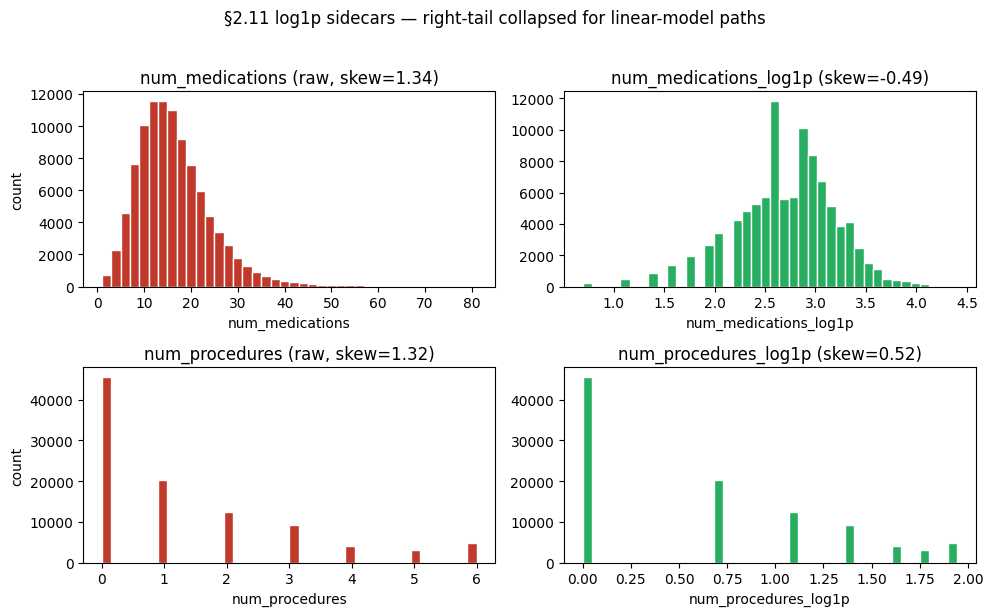

In [39]:
# Visualize the §2.11 log1p sidecars: raw skew vs log-transformed near-symmetry
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for _row, _col in enumerate(["num_medications", "num_procedures"]):
    _logc = f"{_col}_log1p"
    if _col not in _df.columns or _logc not in _df.columns:
        continue
    axes[_row, 0].hist(_df[_col].dropna(), bins=40, color="#c0392b", edgecolor="white")
    axes[_row, 0].set_title(f"{_col} (raw, skew={_df[_col].skew():.2f})")
    axes[_row, 0].set_xlabel(_col)
    axes[_row, 0].set_ylabel("count")
    axes[_row, 1].hist(_df[_logc].dropna(), bins=40, color="#27ae60", edgecolor="white")
    axes[_row, 1].set_title(f"{_logc} (skew={_df[_logc].skew():.2f})")
    axes[_row, 1].set_xlabel(_logc)
plt.suptitle("§2.11 log1p sidecars — right-tail collapsed for linear-model paths", y=1.02)
plt.tight_layout()
plt.show()


**Whether the `*_taking` sidecars actually pay off** is answered downstream by the §5.8 mutual-information ranking and the §6.10 coefficient inspection. Both confirm or disconfirm the design choice on the same cohort that consumes these flags.


**Recap of the cleaning pass.** The raw extract entered §2 with 101,766 encounters and 50 columns. The table below records the running shape after each cleaning step.

| Step | Action | Approximate shape |
| --- | --- | --- |
| §2.4 | Remove deceased and hospice encounters | ~99,700 rows × 50 cols |
| §2.5 | Drop three `Unknown/Invalid`-gender rows | ~99,700 rows × 50 cols |
| §2.6 | Drop `encounter_id`, `weight`, zero-variance drugs, `diabetesMed` | ~99,343 rows × 43 cols |
| §2.10 | Add MNAR indicators, ICD-9 chapter rollup, specialty top-10 rollup | ~99,343 rows × 43 + rollup cols |
| §2.11 | Add `*_taking` drug flags and `log1p` sidecars on heavy-tailed counts | ~99,343 rows × 43 + rollup + sidecar cols |

**Four interpretive headlines that travel downstream.**

* **Informative missingness.** The lab columns `max_glu_serum` and `A1Cresult` are preserved as `"not_measured"` rather than imputed, because the *fact* of not ordering the lab is itself the signal.
* **Zero-variance drugs.** The strictly constant and near-constant drug columns are dropped, so they cannot poison regularization or waste tree splits.
* **`patient_nbr` is a group key, not a feature.** It is retained in the cleaned CSV so notebook 5 can enforce patient-level splits via `GroupKFold`, but it never enters the feature matrix.
* **Deceased and hospice encounters are removed.** Their `readmitted = NO` label is a logical certainty rather than a learnable signal, and keeping them would inflate the negative class with un-modelable rows.

**End of notebook 2.** The cleaned cohort and the lab-Postgres version row are persisted. Notebook 3 (EDA) consumes the CSV and produces the empirical evidence that motivates the feature-engineering decisions in notebook 4.
